# Advanced Task 7: Customer Segmentation using K-Means

## Objective
Segment customers based on spending behavior and income level.

## Dataset
Mall Customers dataset

## Algorithms Used
- K-Means Clustering
- PCA (Principal Component Analysis)

## Goal
Identify customer groups and suggest marketing strategies.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
df = pd.read_csv("dataset/mall_customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [18]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [19]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

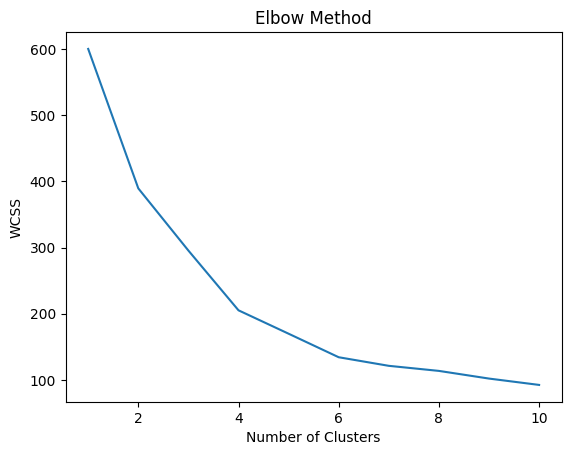

In [21]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [22]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [23]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

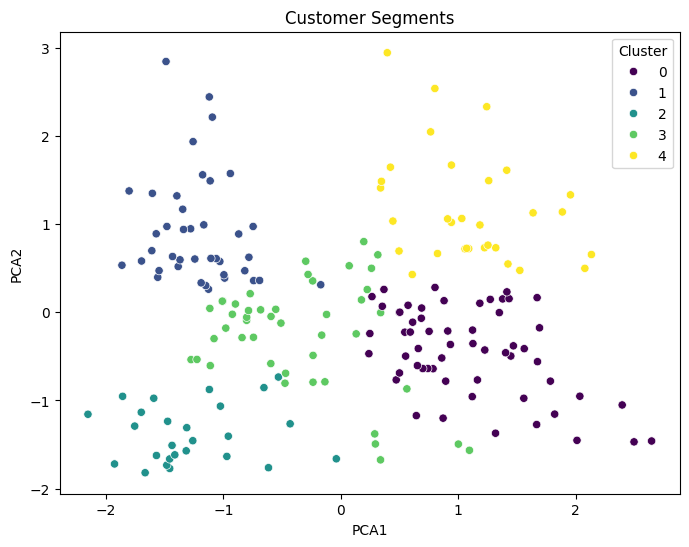

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['PCA1'],
    y=df['PCA2'],
    hue=df['Cluster'],
    palette='viridis'
)

plt.title("Customer Segments")

plt.show()

In [25]:
df.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),PCA1,PCA2
Cluster,,,,,,
0,68.775862,55.275862,47.620690,41.706897,1.089268,-0.445323
1,161.025000,32.875000,86.100000,81.525000,-1.208516,0.914846
2,23.461538,25.769231,26.115385,74.846154,-1.275681,-1.377634
3,86.377778,26.733333,54.311111,40.911111,-0.348135,-0.250826
4,166.870968,44.387097,89.774194,18.483871,1.096673,1.172275


## Customer Segments Insights

Cluster 0:
High income, high spending customers.
Strategy:
Offer premium memberships and exclusive deals.

Cluster 1:
Low income, low spending customers.
Strategy:
Provide discounts and budget-friendly offers.

Cluster 2:
Young customers with medium income and high spending.
Strategy:
Target with trendy products and social media marketing.

Cluster 3:
Older customers with stable income.
Strategy:
Offer loyalty programs and long-term benefits.

Cluster 4:
Customers with high income but low spending.
Strategy:
Encourage spending through personalized offers.

## Conclusion

K-Means clustering successfully grouped customers based on spending habits.

Using PCA visualization, we clearly see distinct clusters.

Businesses can use these insights to design targeted marketing strategies for different customer groups.